In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Problem 1

## Load and Display the Image

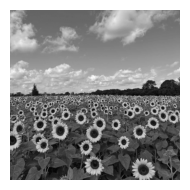

Image shape: (360, 360, 3)
Grayscale shape: (360, 360)


In [5]:
# Load the image
im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)

# Convert to grayscale
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

# Display the original image
plt.figure(figsize=(3, 2))
plt.imshow(im_gray, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {im.shape}")
print(f"Grayscale shape: {im_gray.shape}")

In [6]:
def laplacian_of_gaussian(image, sigma):
    """
    Apply Laplacian of Gaussian filter to the image.
    Scale-normalized version: sigma^2 * LoG
    
    Parameters:
    - image: grayscale image
    - sigma: scale parameter
    
    Returns:
    - Scale-normalized LoG response
    """
    # Apply Gaussian blur
    blurred = cv.GaussianBlur(image.astype(float), (0, 0), sigma)
    
    # Apply Laplacian
    laplacian = cv.Laplacian(blurred, cv.CV_64F)
    
    # Scale normalization: multiply by sigma^2
    # Take absolute value because we're looking for bright blobs on dark background
    return np.abs(sigma**2 * laplacian)

In [9]:
# Select range of sigma values (geometric progression to cover small to large blobs)
sigma_values = np.logspace(np.log10(1.2), np.log10(12.0), num=18)
threshold = 0.045
nms_size = (3, 3, 3)
max_blobs = 200

scale_space = []
print("Computing scale-normalized LoG responses...")
for sigma in sigma_values:
    print(f"  sigma = {sigma:.2f}")
    response = laplacian_of_gaussian(im_gray, sigma)
    response_abs = np.abs(response)
    response_norm = cv.normalize(response_abs, None, 0, 1, cv.NORM_MINMAX)
    scale_space.append(response_norm.astype(np.float32))
    
scale_space = np.stack(scale_space, axis=0)
max_filtered = ndimage.maximum_filter(scale_space, size=nms_size, mode='reflect')
candidate_mask = (scale_space == max_filtered) & (scale_space >= threshold)
candidate_indices = np.argwhere(candidate_mask)
print(f"Total candidates after NMS: {len(candidate_indices)}")

detections = []
for scale_idx, y, x in candidate_indices:
    sigma = float(sigma_values[scale_idx])
    center = (int(x), int(y))
    radius = float(np.sqrt(2) * sigma)
    response_value = float(scale_space[scale_idx, y, x])
    detections.append((center, radius, sigma, response_value))

detections.sort(key=lambda item: item[3], reverse=True)

blob_responses = []
for center, radius, sigma, response_value in detections:
    if len(blob_responses) >= max_blobs:
        break
    keep = True
    for chosen_center, chosen_radius, _, _ in blob_responses:
        dist = np.hypot(center[0] - chosen_center[0], center[1] - chosen_center[1])
        min_sep = 0.6 * max(radius, chosen_radius)
        if dist < min_sep:
            keep = False
            break
    if keep:
        blob_responses.append((center, radius, sigma, response_value))

print(f"Blobs kept after spatial suppression: {len(blob_responses)}")

Computing scale-normalized LoG responses...
  sigma = 1.20
  sigma = 1.37
  sigma = 1.57
  sigma = 1.80
  sigma = 2.06
  sigma = 2.36
  sigma = 2.70
  sigma = 3.10
  sigma = 3.55
  sigma = 4.06
  sigma = 4.65
  sigma = 5.32
  sigma = 6.10
  sigma = 6.98
  sigma = 7.99
  sigma = 9.15
  sigma = 10.48
  sigma = 12.00
Total candidates after NMS: 5282
Blobs kept after spatial suppression: 200


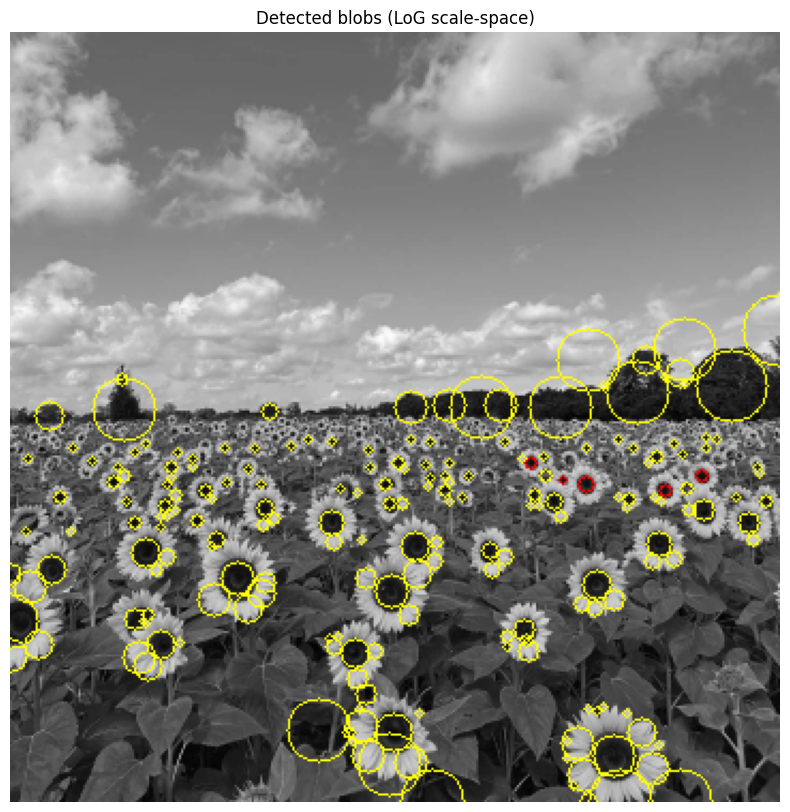

Sigma range: 1.20 – 12.00 (total 18 scales)
Largest blob at : (337, 165) with radius 17.0 px and sigma 12.00
Top 5 blobs by radius:
  1. center=(337, 165), radius=17.0px, sigma=12.00, response=0.994
  2. center=(359, 139), radius=17.0px, sigma=12.00, response=0.722
  3. center=(293, 168), radius=14.8px, sigma=10.48, response=1.000
  4. center=(53, 176), radius=14.8px, sigma=10.48, response=0.888
  5. center=(257, 175), radius=14.8px, sigma=10.48, response=0.854


In [10]:
# Draw all detected circles with the specified line thickness
output = cv.cvtColor(im_gray, cv.COLOR_GRAY2BGR)
for rank, (center, radius, sigma, response_value) in enumerate(blob_responses):
    color = (0, 255, 255) if rank >= 5 else (0, 0, 255)
    cv.circle(output, center, int(round(radius)), color, 1)

# Display the grayscale image with detected circles
plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Detected blobs (LoG scale-space)')
plt.show()

sigma_min, sigma_max = float(sigma_values[0]), float(sigma_values[-1])
print(f"Sigma range: {sigma_min:.2f} – {sigma_max:.2f} (total {len(sigma_values)} scales)")

if blob_responses:
    blobs_sorted = sorted(blob_responses, key=lambda x: x[1], reverse=True)
    largest_blob = blobs_sorted[0]
    center, radius, sigma = largest_blob[:3]
    print(f"Largest blob at : {center} with radius {radius:.1f} px and sigma {sigma:.2f}")
    print("Top 5 blobs by radius:")
    for idx, (c, r, s, resp) in enumerate(blobs_sorted[:5], start=1):
        print(f"  {idx}. center={c}, radius={r:.1f}px, sigma={s:.2f}, response={resp:.3f}")
else:
    print("No blobs detected above the threshold.")